In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/vertical_modes/'

In [318]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['Zl'] = ds_tpose_noTAO.Zl.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['Zl'] = ds_tpose_TAO.Zl.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-29'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


### Select Region

In [319]:
# tpose_ds.ADJetan is t, xc, YG
lat_min = -0.1
lat_max = 0.1
lon = 220
fig_str = '140W'
lat_dim = 'YC'
lon_dim = 'XC'

In [321]:
ds_tpose_noTAO.maskC

<xarray.DataArray 'maskC' (Z: 66, YC: 336, XC: 1128)> Size: 25MB
dask.array<gt, shape=(66, 336, 1128), dtype=bool, chunksize=(66, 336, 1128), chunktype=numpy.ndarray>
Coordinates:
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
  * YC       (YC) float64 3kB -25.92 -25.75 -25.58 -25.42 ... 29.58 29.75 29.92
  * XC       (XC) float64 9kB 104.1 104.2 104.4 104.6 ... 291.6 291.8 291.9
    rA       (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    Depth    (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    drF      (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    PHrefC   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    hFacC    (Z, YC, XC) >f4 100MB dask.array<chunksize=(66, 336, 1128), meta=np.ndarray>
    maskC    (Z, YC, XC) bool 25MB dask.array<chunksize=(66, 336, 1128), meta=np.ndarray>
    dxF      (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    dyF      (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
Attributes:
    standard_name:  sea_binary_mask_at_t_location
    long_name:      mask denoting wet point at center

In [305]:
# 1. Select longitude
ds_col = ds_tpose_noTAO.sel(XC=lon, method='nearest')

# 2. Select latitude slice
ds_col = ds_col.sel(YC=slice(lat_min, lat_max))

# 3. Average over YC
ds_mean = ds_col.mean(dim='YC')

# 4. Handle hFacC separately as a column
hFacC_col = ds_col.hFacC.mean(dim='YC')  # dims: (Z)

# Suppose hFacC_col has dims (Z,) and is Dask-backed
wet_idx = (hFacC_col > 0).argmax(dim="Z").compute()  # first wet cell
nz_water = (hFacC_col > 0).sum(dim="Z").compute()    # number of wet cells

In [306]:
ds_tpose_TAO_crop = ds_tpose_TAO.sel(YC=slice(lat_min,lat_max)).sel(XC=lon,method='nearest').mean(dim='YC')
ds_tpose_noTAO_crop = ds_tpose_noTAO.sel(YC=slice(lat_min,lat_max)).sel(XC=lon,method='nearest').mean(dim='YC')

### Mean Stratification Profile

In [307]:
g = 9.81
rho0 = 1025

## TPOSE with TAO 
N2 = -g / rho0 * ds_tpose_TAO_crop.DRHODR
N2.name = "N2"
N2.attrs["units"] = "s^-2"

N2 = N2.interp(Zl=ds.Z)
N2_mean = N2.mean(dim='time')
N2_mean.values[-1] = N2_mean.values[-2] # fix bottom value to avoid NaN
N2_mean = N2_mean.clip(min=1e-7)

## TPOSE with TAO 
N2_noTAO = -g / rho0 * ds_tpose_noTAO_crop.DRHODR
N2_noTAO.name = "N2_noTAO"
N2_noTAO.attrs["units"] = "s^-2"

N2_noTAO = N2_noTAO.interp(Zl=ds.Z)
N2_mean_noTAO = N2_noTAO.mean(dim='time')
N2_mean_noTAO.values[-1] = N2_mean_noTAO.values[-2] # fix bottom value to avoid NaN
N2_mean_noTAO = N2_mean_noTAO.clip(min=1e-7)

In [308]:
# Slice the Z dimension safely
N2_mean_noTAO = N2_mean_noTAO.isel(Z=slice(0, nz_water.values))
N2_mean = N2_mean.isel(Z=slice(0, nz_water.values))

# zmin = float(N2_mean_noTAO.Zl.min())
# zmax = float(N2_mean_noTAO.Zl.max())
# z_uniform = np.arange(zmin, zmax + 5, 5)

# N2_mean_noTAO = N2_mean_noTAO.interp(Zl=z_uniform)
# N2_mean = N2_mean.interp(Zl=z_uniform)

# N2_mean_noTAO = N2_mean_noTAO.rolling(Zl=30, center=True, min_periods=1).mean()
# N2_mean = N2_mean.rolling(Zl=30, center=True, min_periods=1).mean()
N2_mean = N2_mean.compute()
N2_mean_noTAO = N2_mean_noTAO.compute()

### Vertical Mode Decomposition

In [260]:
import numpy as np
import xarray as xr
from scipy.linalg import eigh


def baroclinic_modes(N2, nmodes=3, zdim="z"):

    z = N2[zdim].values
    N2v = N2.values.copy()

    # ensure increasing z
    if z[1] < z[0]:
        z = z[::-1]
        N2v = N2v[::-1]

    # avoid singularities
    N2v = np.maximum(N2v, 1e-7)

    nz = len(z)

    dz = np.diff(z)

    A = np.zeros((nz, nz))

    invN2 = 1 / N2v

    for i in range(1, nz-1):

        dz_up = z[i+1] - z[i]
        dz_dn = z[i] - z[i-1]

        inv_up = 0.5 * (invN2[i] + invN2[i+1])
        inv_dn = 0.5 * (invN2[i] + invN2[i-1])

        A[i,i-1] =  inv_dn / dz_dn**2
        A[i,i]   = -(inv_up/dz_up**2 + inv_dn/dz_dn**2)
        A[i,i+1] =  inv_up / dz_up**2

    # Neumann BC
    A[0,0] = -1
    A[0,1] = 1
    A[-1,-1] = -1
    A[-1,-2] = 1

    eigvals, eigvecs = eigh(-A)

    eigvals = eigvals[1:nmodes+1]
    eigvecs = eigvecs[:,1:nmodes+1]

    # ---- enforce consistent eigenfunction sign ----
    for m in range(eigvecs.shape[1]):
        imax = np.argmax(np.abs(eigvecs[:, m]))
        if eigvecs[imax, m] < 0:
            eigvecs[:, m] *= -1
    # -----------------------------------------------

    c = 1 / np.sqrt(eigvals)

    modes = xr.DataArray(
        eigvecs,
        coords={zdim: z, "mode": np.arange(1, nmodes+1)},
        dims=(zdim, "mode")
    )

    c = xr.DataArray(
        c,
        coords={"mode": np.arange(1, nmodes+1)},
        dims="mode"
    )

    return modes, c

In [261]:
# N2_smooth = (
#     N2_mean
#     .rolling({"Z":5}, center=True)
#     .mean()
#     .ffill("Z")
#     .bfill("Z")
# )

# N2_smooth_noTAO = (
#     N2_mean_noTAO
#     .rolling({"Z":5}, center=True)
#     .mean()
#     .ffill("Z")
#     .bfill("Z")
# )

In [262]:
# N2_mean = N2_mean.compute()
# N2_smooth = N2_smooth.compute()
# N2_mean_noTAO = N2_mean_noTAO.compute()
# N2_smooth_noTAO = N2_smooth_noTAO.compute()

In [309]:
n_modes = 2
modes, c = baroclinic_modes(N2_mean, nmodes=n_modes, zdim='Z')
modes_noTAO, c_noTAO = baroclinic_modes(N2_mean_noTAO, nmodes=n_modes, zdim='Z')

In [310]:
modes = modes / np.sqrt((modes**2).integrate("Z"))
modes_noTAO = modes_noTAO / np.sqrt((modes_noTAO**2).integrate("Z"))

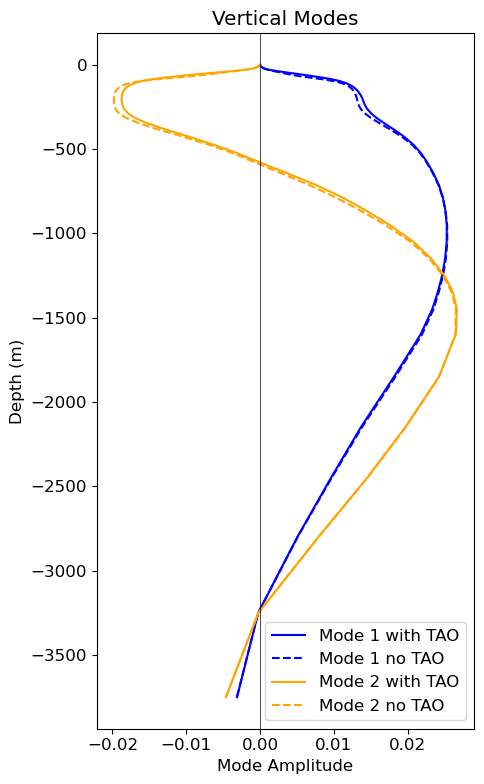

In [281]:
colors = ['blue', 'orange', 'green', 'red']
fig, ax = plt.subplots(figsize=(5,8))
for n in range(1,n_modes+1):
    color = colors[n-1]
    modes.sel(mode=n).plot(ax=ax, y='Z', color=color, label=f'Mode {n} with TAO')
    modes_noTAO.sel(mode=n).plot(ax=ax, y='Z', color=color, label=f'Mode {n} no TAO', linestyle='--')
ax.set_xlabel('Mode Amplitude')
ax.set_ylabel('Depth (m)')
ax.legend(loc='lower right')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Vertical Modes')

plt.tight_layout()
fig.savefig(foldername + 'baroclinic_modes_unsmoothed_normalized_' + fig_str + '.png', dpi=300)

### Look at U Projected Onto Modes

In [282]:
mean_u = ds_tpose_TAO_crop.UVEL.sel(XG=lon, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')
mean_v = ds_tpose_TAO_crop.VVEL.sel(YG=0.0, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')
u_proj = (mean_u.values * modes.sel(mode=1)).integrate("Z")
v_proj = (mean_v.values * modes.sel(mode=1)).integrate("Z")
u_mode_1 = u_proj * modes.sel(mode=1)
v_mode_1 = v_proj * modes.sel(mode=1)
u_proj = (mean_u.values * modes.sel(mode=2)).integrate("Z")
v_proj = (mean_v.values * modes.sel(mode=2)).integrate("Z")
u_mode_2 = u_proj * modes.sel(mode=2)
v_mode_2 = v_proj * modes.sel(mode=2)
# u_proj = (mean_u.values * modes.sel(mode=3)).integrate("Z")
# v_proj = (mean_v.values * modes.sel(mode=3)).integrate("Z")
# u_mode_3 = u_proj * modes.sel(mode=3)
# v_mode_3 = v_proj * modes.sel(mode=3)

In [283]:
mean_u_noTAO = ds_tpose_noTAO_crop.UVEL.sel(XG=lon, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')
mean_v_noTAO = ds_tpose_noTAO_crop.VVEL.sel(YG=0.0, method='nearest').isel(Z=slice(0, nz_water.values)).mean(dim='time')
u_proj_noTAO = (mean_u_noTAO.values * modes_noTAO.sel(mode=1)).integrate("Z")
v_proj_noTAO = (mean_v_noTAO.values * modes_noTAO.sel(mode=1)).integrate("Z")
u_mode_1_noTAO = u_proj_noTAO * modes_noTAO.sel(mode=1)
v_mode_1_noTAO = v_proj_noTAO * modes_noTAO.sel(mode=1)
u_proj_noTAO = (mean_u_noTAO.values * modes_noTAO.sel(mode=2)).integrate("Z")
v_proj_noTAO = (mean_v_noTAO.values * modes_noTAO.sel(mode=2)).integrate("Z")
u_mode_2_noTAO = u_proj_noTAO * modes_noTAO.sel(mode=2)
v_mode_2_noTAO = v_proj_noTAO * modes_noTAO.sel(mode=2)
# u_proj_noTAO = (mean_u_noTAO.values * modes_noTAO.sel(mode=3)).integrate("Z")
# v_proj_noTAO = (mean_v_noTAO.values * modes_noTAO.sel(mode=3)).integrate("Z")
# u_mode_3_noTAO = u_proj_noTAO * modes_noTAO.sel(mode=3)
# v_mode_3_noTAO = v_proj_noTAO * modes_noTAO.sel(mode=3)

In [ ]:
plt.rcParams['font.size'] = 12

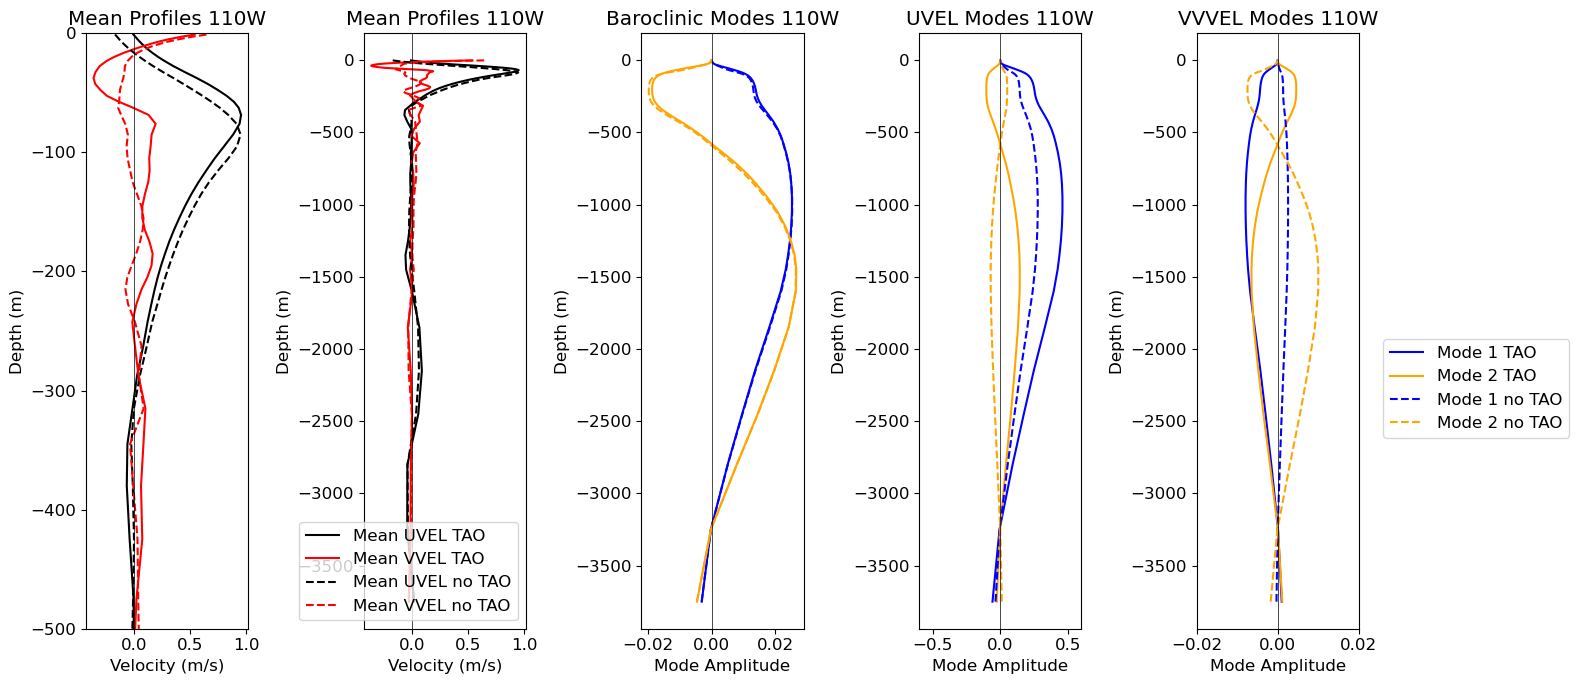

In [228]:
n=1
fig, ax = plt.subplots(figsize=(16,7), ncols=5)
mean_u.plot(ax=ax[0], y='Z', color='black', label='Mean UVEL TAO')
(mean_v*10).plot(ax=ax[0], y='Z', color='red', label='Mean VVEL TAO')
mean_u_noTAO.plot(ax=ax[0], y='Z', color='black', linestyle='--', label='Mean UVEL no TAO')
(mean_v_noTAO*10).plot(ax=ax[0], y='Z', color='red', linestyle='--', label='Mean VVEL no TAO')

mean_u.plot(ax=ax[1], y='Z', color='black', label='Mean UVEL TAO')
(mean_v*10).plot(ax=ax[1], y='Z', color='red', label='Mean VVEL TAO')
mean_u_noTAO.plot(ax=ax[1], y='Z', color='black', linestyle='--', label='Mean UVEL no TAO')
(mean_v_noTAO*10).plot(ax=ax[1], y='Z', color='red', linestyle='--', label='Mean VVEL no TAO')

colors = ['blue', 'orange', 'green', 'red']
for n in range(1,n_modes+1):
    color = colors[n-1]
    modes.sel(mode=n).plot(ax=ax[2], y='Z', color=color, label=f'Mode {n} TAO')
    modes_noTAO.sel(mode=n).plot(ax=ax[2], y='Z', color=color, label=f'Mode {n} no TAO', linestyle='--')

u_mode_1.plot(ax=ax[3], y='Z', color='blue', label=f'Mode 1 UVEL TAO')
v_mode_1.plot(ax=ax[4], y='Z', color='blue', label=f'Mode 1 TAO')
u_mode_2.plot(ax=ax[3], y='Z', color='orange', label=f'Mode 2 UVEL TAO')
v_mode_2.plot(ax=ax[4], y='Z', color='orange', label=f'Mode 2 TAO')
# u_mode_3.plot(ax=ax[3], y='Z', color='green', label=f'Mode 3 UVEL TAO')
# v_mode_3.plot(ax=ax[4], y='Z', color='green', label=f'Mode 3 TAO')

u_mode_1_noTAO.plot(ax=ax[3], y='Z', color='blue', linestyle='--', label=f'Mode 1 UVEL no TAO')
v_mode_1_noTAO.plot(ax=ax[4], y='Z', color='blue', linestyle='--', label=f'Mode 1 no TAO')
u_mode_2_noTAO.plot(ax=ax[3], y='Z', color='orange', linestyle='--', label=f'Mode 2 UVEL no TAO')
v_mode_2_noTAO.plot(ax=ax[4], y='Z', color='orange', linestyle='--', label=f'Mode 2 no TAO')
# u_mode_3_noTAO.plot(ax=ax[3], y='Z', color='green', linestyle='--', label=f'Mode 3 UVEL no TAO')
# v_mode_3_noTAO.plot(ax=ax[4], y='Z', color='green', linestyle='--', label=f'Mode 3 no TAO')

ax[0].set_title('Mean Profiles '+ fig_str)
ax[0].set_ylim(-500,0)
ax[1].set_title('Mean Profiles '+ fig_str)
ax[2].set_title('Baroclinic Modes '+ fig_str)
ax[3].set_title('UVEL Modes '+ fig_str)
ax[3].set_xlim(-0.6,0.6)
ax[4].set_title('VVVEL Modes '+ fig_str)
ax[4].set_xlim(-0.02,0.02)
ax[1].legend(loc='lower right')
ax[4].legend(bbox_to_anchor=(1.1, 0.5))
for axis in ax.flatten()[0:2]:
    axis.set_xlabel('Velocity (m/s)')
    axis.set_ylabel('Depth (m)')
    axis.axvline(0, color='k', linewidth=0.5)

for axis in ax.flatten()[-3:]:
    axis.set_xlabel('Mode Amplitude')
    axis.set_ylabel('Depth (m)')
    axis.axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
fig.savefig(foldername + 'vel_modes_'+ fig_str + '_unsmoothed.png', dpi=300)

### Energy Flux

In [317]:
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

p = gsw.p_from_z(ds_tpose_TAO_crop.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO_crop.SALT, p, ds_tpose_TAO_crop.XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO_crop.THETA)
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_TAO_crop.THETA.copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_TAO_crop.THETA.maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_TAO.drF * ds_tpose_TAO.hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')
p_prime = p_prime.isel(Z=slice(0, nz_water.values))

AttributeError: 'DataArray' object has no attribute 'maskC'

In [312]:
import xarray as xr
import numpy as np

# -----------------------------
# -----------------------------
u = ds_tpose_TAO_crop.UVEL.sel(XG=lon, method='nearest').isel(Z=slice(0, nz_water.values))

# 1. remove time mean to get anomalies
u_prime = u - u.mean(dim='time')
# p_prime = p - p.mean(dim='time')

# 2. project onto mode (inner product over depth)
dz = np.gradient(u.Z.values)
u_proj = (u_prime.values * modes.sel(mode=1).values[np.newaxis,:]).dot(dz)
p_proj = (p_prime.values * modes.sel(mode=1).values[np.newaxis,:]).dot(dz)

# 3. compute mode 1 energy flux (time-dependent)
# F_x = <u1 * p1>
F1_time = u_proj * p_proj  # W/m^2 if units consistent

# F1_time_linear = rho0 * c1**2 * u_proj**2  # optionally use rho*c1*u = p for linear baroclinic modes
# 5. time-mean flux
F1_mean = F1_time.mean(axis=0)

In [313]:
F1_mean

np.float64(783.8723063455574)

In [314]:
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

p = gsw.p_from_z(ds_tpose_noTAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_noTAO.sel(XC=lon,YC=0.0,method='nearest').maskC)

# 2. pressure anomaly
rho_anomaly = (rho - rho.mean(dim='time'))  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
rho_dz = rho_anomaly * ds_tpose_noTAO.drF * ds_tpose_noTAO.sel(XC=lon,YC=0.0,method='nearest').hFacC  # shape (time, z)

# cumulative sum along vertical axis
p_prime = g*rho_dz.cumsum(dim='Z')
p_prime = p_prime.isel(Z=slice(0, nz_water.values))

In [315]:
# -----------------------------
# -----------------------------
u = ds_tpose_noTAO_crop.UVEL.sel(XG=lon, method='nearest').isel(Z=slice(0, nz_water.values))

# 1. remove time mean to get anomalies
u_prime = u - u.mean(dim='time')
# p_prime = p - p.mean(dim='time')

# 2. project onto mode (inner product over depth)
dz = np.gradient(u.Z.values)
u_proj = (u_prime.values * modes_noTAO.sel(mode=1).values[np.newaxis,:]).dot(dz)
p_proj = (p_prime.values * modes_noTAO.sel(mode=1).values[np.newaxis,:]).dot(dz)

# 3. compute mode 1 energy flux (time-dependent)
# F_x = <u1 * p1>
F1_time = u_proj * p_proj  # W/m^2 if units consistent

# F1_time_linear = rho0 * c1**2 * u_proj**2  # optionally use rho*c1*u = p for linear baroclinic modes
# 5. time-mean flux
F1_mean_noTAO = F1_time.mean(axis=0)

KeyboardInterrupt: 

In [ ]:
F1_mean_noTAO

np.float64(-249.88462347279923)

In [322]:
cluster.close()
client.shutdown()